# Exercise 4.10 - part 1 (Q&A: 1-4)

## Table of content
1.1 Importing Libraries 

1.2 Importing Data Sets

2. Data security implications
3. Geographical customer behaviour
4. Low activity customers

# 1.1. Importing Libraries

In [3]:
# Importing analysis and visual libraries

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# 1.2. Importing Data Set

In [8]:
# Creating path

In [10]:
path=r'/Users/konstant/Documents/Achievement 4. Instacart Basket Analysis'

In [12]:
# Importing most up-to-date data set.

In [14]:
df_final_merge= pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'df_final_merge.pkl'))



In [16]:
df_final_merge.shape

(32404859, 32)

# 2. Data security implications

In [19]:
# Check the column headers for any columns that might contain PII

In [21]:
df_final_merge.columns.tolist()

['product_id',
 'product_name',
 'aisle_id',
 'department_id',
 'prices',
 'order_id',
 'user_id',
 'order_number',
 'orders_day_of_week',
 'hour_of_purchase',
 'days_since_prior_order',
 'add_to_cart_order',
 'reordered',
 'price_range_loc',
 'busiest_days',
 'busiest_period_of_day',
 'max_order',
 'loyalty_flag',
 'max_spend',
 'spending_flag',
 'days_since_last_order_median',
 'order_frequency_flag',
 'first_name',
 'last_name',
 'gender',
 'state',
 'age',
 'date_joined',
 'num_of_dependants',
 'fam_status',
 'income',
 '_merge']

### The columns: 'first_name' and 'last_name' contains the customers first and last name, which could be used to trace back to a particular person, and is thus in breach of the data privacy regulations. The recommendation is thus to drop these columns by creating a new version of the data frame that do not include them.

In [24]:
# creating a new non-PII version of the data frame. 

In [28]:
df_final_merge_non_pii=df_final_merge.drop(columns=['first_name','last_name',])

In [29]:
df_final_merge_non_pii.columns.tolist()

['product_id',
 'product_name',
 'aisle_id',
 'department_id',
 'prices',
 'order_id',
 'user_id',
 'order_number',
 'orders_day_of_week',
 'hour_of_purchase',
 'days_since_prior_order',
 'add_to_cart_order',
 'reordered',
 'price_range_loc',
 'busiest_days',
 'busiest_period_of_day',
 'max_order',
 'loyalty_flag',
 'max_spend',
 'spending_flag',
 'days_since_last_order_median',
 'order_frequency_flag',
 'gender',
 'state',
 'age',
 'date_joined',
 'num_of_dependants',
 'fam_status',
 'income',
 '_merge']

# 3. Geographical customer behaviour

In [33]:
# creating a new colmn: 'region' based on the 'state' column.

In [35]:
# Firstly defining the results of the region.

In [37]:
result=[]

In [39]:
region_1 = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut', 'New York', 'Pennsylvania', 'New Jersey']
region_2 = ['Wisconsin', 'Michigan', 'Illinois', 'Indiana', 'Ohio', 'North Dakota', 'South Dakota', 'Nebraska', 'Kansas', 'Minnesota', 'Iowa', 'Missouri']
region_3 = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Kentucky', 'Tennessee', 'Mississippi', 'Alabama', 'Oklahoma', 'Texas', 'Arkansas', 'Louisiana']
region_4 = ['Idaho', 'Montana', 'Wyoming', 'Nevada', 'Utah', 'Colorado', 'Arizona', 'New Mexico', 'Alaska', 'Washington', 'Oregon', 'California', 'Hawaii']

In [41]:
# Now running the column though the result to get the correct region.

In [43]:
for value in df_final_merge_non_pii['state']:
    if value in region_1:
        result.append('Region 1 (Northeast)')
    elif value in region_2:
        result.append('Region 2 (Midwest)')
    elif value in region_3:
        result.append('Region 3 (South)')
    elif value in region_4:
        result.append('Region 4 (West)')
    else:
        result.append('Missing state')

In [45]:
# After the list is created, we need to combining the results into a new column. 

In [47]:
df_final_merge_non_pii['region']=result

In [49]:
# checking that the column has been added.

In [51]:
df_final_merge_non_pii.head(1)

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,hour_of_purchase,...,order_frequency_flag,gender,state,age,date_joined,num_of_dependants,fam_status,income,_merge,region
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,Frequent customer,Male,Minnesota,81,8/1/2019,1,married,49620,both,Region 2 (Midwest)


In [53]:
# and checking the results using value counts

In [55]:
df_final_merge_non_pii['region'].value_counts(dropna=False)

region
Region 3 (South)        10791885
Region 4 (West)          8292913
Region 2 (Midwest)       7597325
Region 1 (Northeast)     5722736
Name: count, dtype: int64

In [57]:
# now creating a cross tab between the 'region' and 'spending_flag'

In [59]:
crosstab = pd.crosstab(df_final_merge_non_pii['region'], df_final_merge_non_pii['spending_flag'], dropna = False)

In [61]:
# Copying to clipboard and pasting into an excel sheet

In [63]:
crosstab.to_clipboard()

In [65]:
# Below is the table as it appears in Excel: 

### Results from excel
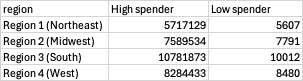

### Region 3 (South) is the biggest spending region. Region 2 and 4 (West) follows as the second biggest spending region. Region 1 (Northeast) is the lowest spending region. Each region also contains low spenders, however, this is only a very small percentage compared to the high spenders. 

# 4. Low activity customers

In [70]:
# creating the condition for low actvity customers (< 5 orders) with the loc() function and placing the results in a new column:'exclusion flag'


In [72]:
df_final_merge_non_pii.loc[df_final_merge_non_pii['max_order'] < 5, 'exclusion_flag'] = 'Low activity customer'


In [74]:
df_final_merge_non_pii.loc[df_final_merge_non_pii['max_order'] >= 5, 'exclusion_flag'] = 'Normal activity customer'

In [76]:
# Checking results

In [78]:
df_final_merge_non_pii['exclusion_flag'].value_counts(dropna=False)

exclusion_flag
Normal activity customer    30964564
Low activity customer        1440295
Name: count, dtype: int64

In [82]:
# Isolating the 'low activity customers' by creating a subset. 

In [84]:
df_low_activity_customers=df_final_merge_non_pii[df_final_merge_non_pii['exclusion_flag']=='Low activity customer']

In [86]:
# checking results

In [88]:
df_low_activity_customers.head(2)

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,hour_of_purchase,...,gender,state,age,date_joined,num_of_dependants,fam_status,income,_merge,region,exclusion_flag
3,1,Chocolate Sandwich Cookies,61,19,5.8,652770,764,1,3,13,...,Female,Wisconsin,40,2/9/2020,3,married,31308,both,Region 2 (Midwest),Low activity customer
4,1,Chocolate Sandwich Cookies,61,19,5.8,1813452,764,3,4,17,...,Female,Wisconsin,40,2/9/2020,3,married,31308,both,Region 2 (Midwest),Low activity customer


In [90]:
# Now exporting this sample as a pickle file

In [92]:
df_low_activity_customers.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'low_activity_customers.pkl'))

In [94]:
# Now removing this subset from the data frame by overwriting it with only 'normal activity customers'

In [96]:
df_final_merge_non_pii=df_final_merge_non_pii[df_final_merge_non_pii['exclusion_flag']=='Normal activity customer']

In [98]:
# checkign results

In [100]:
df_final_merge_non_pii['exclusion_flag'].value_counts(dropna=False)

exclusion_flag
Normal activity customer    30964564
Name: count, dtype: int64

In [102]:
#Exporting updated data frame as 'final_merge_non_pii_part1.pkl' to continue with in part 2

In [104]:
df_final_merge_non_pii.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'final_merge_non_pii_part1.pkl'))